### Mount Google Drive

First, we need to mount your Google Drive to access the file. When you run the following cell, you will be prompted to authorize Colab to access your Google Drive files. Follow the instructions to complete the mounting process.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Load the Excel file

Now that your Drive is mounted, we can specify the path to your Excel file and load it into a pandas DataFrame. Make sure to replace `'Your_path_to_Online_retail_II.xlsx'` with the actual path to your file in Google Drive. For example, if it's in the root of your drive, the path would be `/content/drive/MyDrive/Online_retail_II.xlsx`.

In [ ]:
import pandas as pd

# The file was found inside the unzipped archive, and is extracted to this path.
# The Excel file contains two sheets, which are loaded separately in a subsequent cell.
file_path = '/tmp/online_retail_data/online_retail_II.xlsx'

# The previous attempt to load the entire Excel file into a single DataFrame failed
# and is now handled by loading individual sheets in cell DxuEZguU6kPH.

### Verify File Path

To help locate the file, you can list the contents of your Google Drive's root directory. Run the cell below and look for your Excel file to ensure the path and filename are correct.

### Unzip the dataset

Since the file identified in your Google Drive is a `.zip` archive, we need to extract its contents first. We'll unzip it into a temporary directory. After unzipping, we'll assume the Excel file inside is named `online_retail_II.xlsx` and then try to load it.

# New Section

In [ ]:
import zipfile
import os

zip_file_path = '/content/drive/MyDrive/online+retail+ii.zip'
extraction_path = '/tmp/online_retail_data'

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"File unzipped to: {extraction_path}")

# List the contents of the extracted folder to verify
!ls {extraction_path}

File unzipped to: /tmp/online_retail_data
online_retail_II.xlsx


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
file_path = '/tmp/online_retail_data/online_retail_II.xlsx'


raw_2009_2010 = pd.read_excel(file_path, sheet_name='Year 2009-2010')
raw_2010_2011 = pd.read_excel(file_path, sheet_name='Year 2010-2011')

print(raw_2009_2010.shape)
print(raw_2010_2011.shape)

print(raw_2009_2010.head())
print(raw_2010_2011.head())

(525461, 8)
(541910, 8)
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom  
  Invoice StockCode                          Description  Quantity  \
0  536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1  536365     71053                  WHITE METAL LANTER

CLEANING FUNCTION



In [ ]:
def clean_online_retail(df_raw, year_label):
    dfc = df_raw.copy()

    # 1) Standardize column names
    dfc.columns = [c.strip().lower().replace(' ', '_') for c in dfc.columns]
    dfc = dfc.rename(columns={
        'invoice': 'invoice_no',
        'stockcode': 'stock_code',
        'invoicedate': 'invoice_date',
        'price': 'unit_price',
        'customer_id': 'customer_id'
    })

    # 2) Coerce types
    dfc['invoice_no'] = dfc['invoice_no'].astype(str).str.strip()
    dfc['stock_code'] = dfc['stock_code'].astype(str).str.strip()

    dfc['description'] = dfc['description'].astype('string').str.strip()
    dfc.loc[dfc['description'].isna() | (dfc['description'].str.len() == 0), 'description'] = pd.NA

    dfc['country'] = dfc['country'].astype('string').str.strip()

    dfc['invoice_date'] = pd.to_datetime(dfc['invoice_date'], errors='coerce')
    dfc['quantity'] = pd.to_numeric(dfc['quantity'], errors='coerce')
    dfc['unit_price'] = pd.to_numeric(dfc['unit_price'], errors='coerce')
    dfc['customer_id'] = pd.to_numeric(dfc['customer_id'], errors='coerce')

    # 3) Flags
    dfc['is_cancelled'] = dfc['invoice_no'].str.upper().str.startswith('C')
    dfc['has_customer_id'] = dfc['customer_id'].notna()

    # 4) Drop rows missing essentials
    dfc = dfc[dfc['invoice_date'].notna()].copy()
    dfc = dfc[dfc['stock_code'].notna()].copy()
    dfc = dfc[dfc['quantity'].notna()].copy()
    dfc = dfc[dfc['unit_price'].notna()].copy()

    # 5) Remove distortion-heavy values for standard EDA
    # Keep cancellations in the dataset (they're meaningful), but remove zero qty and non-positive price
    dfc = dfc[(dfc['unit_price'] > 0) & (dfc['quantity'] != 0)].copy()

    # 6) Derived fields for EDA
    dfc['line_revenue'] = dfc['quantity'] * dfc['unit_price']
    dfc['year_sheet'] = year_label
    dfc['invoice_day'] = dfc['invoice_date'].dt.date
    dfc['invoice_month'] = dfc['invoice_date'].dt.to_period('M').astype(str)

    # 7) Remove exact duplicate rows
    dfc = dfc.drop_duplicates()

    return dfc

CLEAN EACH SHEET + COMBINE

In [ ]:
clean_0910 = clean_online_retail(raw_2009_2010, '2009-2010')
clean_1011 = clean_online_retail(raw_2010_2011, '2010-2011')

online_retail_clean = pd.concat([clean_0910, clean_1011], ignore_index=True)

print(clean_0910.shape)
print(clean_1011.shape)
print(online_retail_clean.shape)

print(online_retail_clean.head())

(514912, 14)
(534130, 14)
(1049042, 14)
  invoice_no stock_code                          description  quantity  \
0     489434      85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1     489434     79323P                   PINK CHERRY LIGHTS        12   
2     489434     79323W                  WHITE CHERRY LIGHTS        12   
3     489434      22041          RECORD FRAME 7" SINGLE SIZE        48   
4     489434      21232       STRAWBERRY CERAMIC TRINKET BOX        24   

         invoice_date  unit_price  customer_id         country  is_cancelled  \
0 2009-12-01 07:45:00        6.95      13085.0  United Kingdom         False   
1 2009-12-01 07:45:00        6.75      13085.0  United Kingdom         False   
2 2009-12-01 07:45:00        6.75      13085.0  United Kingdom         False   
3 2009-12-01 07:45:00        2.10      13085.0  United Kingdom         False   
4 2009-12-01 07:45:00        1.25      13085.0  United Kingdom         False   

   has_customer_id  line_revenue y

 Create EDA-ready “default” view (remove cancellations)

 For most sales EDA you’ll want purchases only (no returns/cancellations). We keep cancellations separately for later analysis.



In [ ]:
online_retail_eda = online_retail_clean.loc[~online_retail_clean['is_cancelled']].copy()
online_retail_returns = online_retail_clean.loc[online_retail_clean['is_cancelled']].copy()

print(online_retail_eda.shape)
print(online_retail_returns.shape)

print(online_retail_eda.head())
print(online_retail_returns.head())

(1029609, 14)
(19433, 14)
  invoice_no stock_code                          description  quantity  \
0     489434      85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1     489434     79323P                   PINK CHERRY LIGHTS        12   
2     489434     79323W                  WHITE CHERRY LIGHTS        12   
3     489434      22041          RECORD FRAME 7" SINGLE SIZE        48   
4     489434      21232       STRAWBERRY CERAMIC TRINKET BOX        24   

         invoice_date  unit_price  customer_id         country  is_cancelled  \
0 2009-12-01 07:45:00        6.95      13085.0  United Kingdom         False   
1 2009-12-01 07:45:00        6.75      13085.0  United Kingdom         False   
2 2009-12-01 07:45:00        6.75      13085.0  United Kingdom         False   
3 2009-12-01 07:45:00        2.10      13085.0  United Kingdom         False   
4 2009-12-01 07:45:00        1.25      13085.0  United Kingdom         False   

   has_customer_id  line_revenue year_sheet invo

 Quick sanity checks (optional but recommended before EDA)
This step checks missingness and a few “does this look reasonable?” counts.


In [ ]:
print(online_retail_clean.isna().mean().sort_values(ascending=False) * 100)

print((online_retail_clean['unit_price'] <= 0).sum())
print((online_retail_clean['quantity'] == 0).sum())

print(online_retail_clean['invoice_no'].nunique())
print(online_retail_eda['invoice_no'].nunique())

customer_id        22.567733
invoice_no          0.000000
description         0.000000
quantity            0.000000
invoice_date        0.000000
stock_code          0.000000
unit_price          0.000000
country             0.000000
is_cancelled        0.000000
has_customer_id     0.000000
line_revenue        0.000000
year_sheet          0.000000
invoice_day         0.000000
invoice_month       0.000000
dtype: float64
0
0
48369
40077


In [ ]:
print("\nDescriptive statistics for numerical columns in online_retail_eda:")
display(online_retail_eda.describe())

print("\nDataFrame Info (data types, non-null counts, memory usage):")
online_retail_eda.info()


Descriptive statistics for numerical columns in online_retail_eda:


,quantity,invoice_date,unit_price,customer_id,line_revenue
count,1.029609e+06,1029609,1.029609e+06,793609.000000,1.029609e+06
mean,1.105795e+01,2011-01-03 19:35:55.374282752,4.094842e+00,15325.072507,2.031246e+01
min,1.000000e+00,2009-12-01 07:45:00,1.000000e-03,12346.000000,1.000000e-03
25%,1.000000e+00,2010-07-12 10:54:00,1.250000e+00,13975.000000,4.130000e+00
50%,3.000000e+00,2010-12-07 18:36:00,2.100000e+00,15255.000000,1.008000e+01
75%,1.200000e+01,2011-07-24 12:05:00,4.150000e+00,16797.000000,1.770000e+01
max,8.099500e+04,2011-12-09 12:50:00,2.511109e+04,18287.000000,1.684696e+05
std,1.272405e+02,NaN,5.174728e+01,1697.397406,2.042938e+02



DataFrame Info (data types, non-null counts, memory usage):
<class 'pandas.core.frame.DataFrame'>
Index: 1029609 entries, 0 to 1049041
Data columns (total 14 columns):
 #   Column           Non-Null Count    Dtype         
---  ------           --------------    -----         
 0   invoice_no       1029609 non-null  object        
 1   stock_code       1029609 non-null  object        
 2   description      1029609 non-null  string        
 3   quantity         1029609 non-null  int64         
 4   invoice_date     1029609 non-null  datetime64[ns]
 5   unit_price       1029609 non-null  float64       
 6   customer_id      793609 non-null   float64       
 7   country          1029609 non-null  string        
 8   is_cancelled     1029609 non-null  bool          
 9   has_customer_id  1029609 non-null  bool          
 10  line_revenue     1029609 non-null  float64       
 11  year_sheet       1029609 non-null  object        
 12  invoice_day      1029609 non-null  object        
 13  i

### Distribution of Quantity

Let's visualize the distribution of the `quantity` column using a histogram to identify potential outliers.

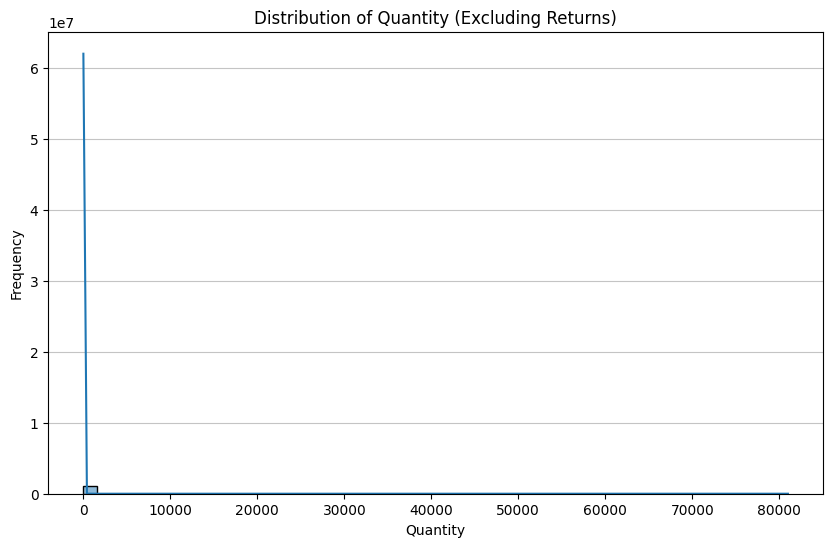

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(online_retail_eda['quantity'], bins=50, kde=True)
plt.title('Distribution of Quantity (Excluding Returns)')
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Outlier Analysis: Quantity

From the histogram, we saw a long tail indicating large quantities. Let's use a box plot to get a clearer view of outliers in the `quantity` column. We will also set a reasonable upper bound for visualization, as extreme outliers can make the plot unreadable.

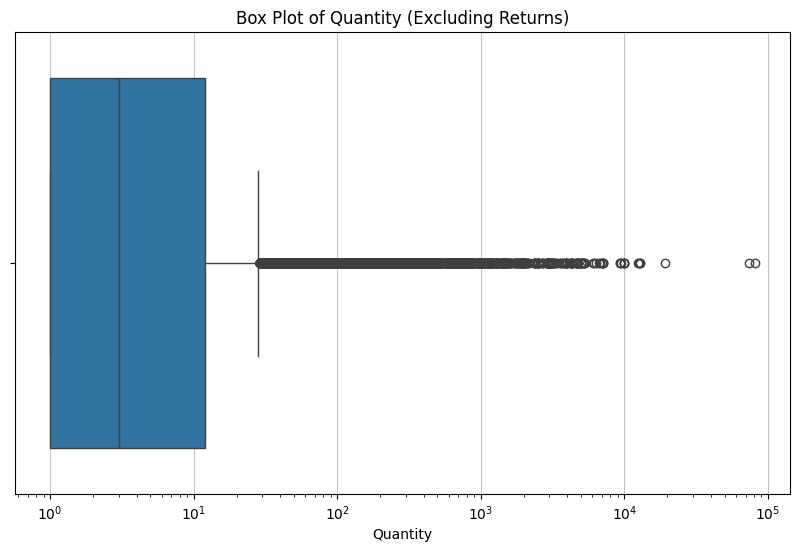

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=online_retail_eda['quantity'])
plt.title('Box Plot of Quantity (Excluding Returns)')
plt.xlabel('Quantity')
plt.xscale('log') # Use a log scale to better visualize the wide range of values
plt.grid(axis='x', alpha=0.75)
plt.show()

### Outlier Analysis: Unit Price

Similarly, let's examine the `unit_price` column for outliers. This is crucial as extreme prices can heavily skew revenue calculations and other analyses.

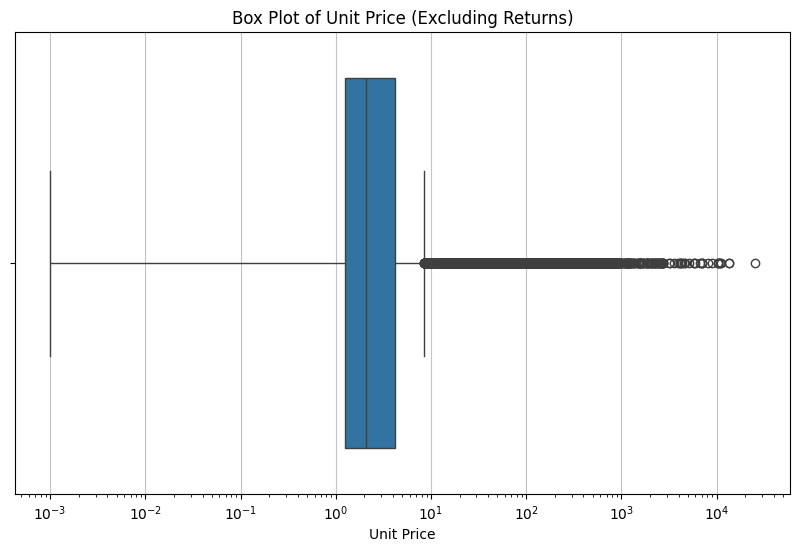

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=online_retail_eda['unit_price'])
plt.title('Box Plot of Unit Price (Excluding Returns)')
plt.xlabel('Unit Price')
plt.xscale('log') # Use a log scale for better visualization if values span several orders of magnitude
plt.grid(axis='x', alpha=0.75)
plt.show()

### Addressing Missing Customer IDs

We previously noted that approximately 22.57% of `customer_id` values are missing. Depending on the analysis, these rows might need to be handled. Here are a few common strategies:

1.  **Drop rows with missing `customer_id`**: If the analysis strictly requires customer identification (e.g., for RFM analysis, customer segmentation), these rows can be dropped.
2.  **Impute missing values**: If possible, missing IDs could be imputed (though this is often difficult and risky for unique identifiers).
3.  **Treat as 'guest' purchases**: Assign a new, unique identifier (e.g., 'Guest') to all transactions without a `customer_id` if the goal is to analyze overall sales without individual customer tracking.

For most customer-centric analyses, dropping them is often the safest bet. However, for overall sales trend analysis, they can still contribute to `line_revenue` if other data is complete.

### Sales Distribution by Country

To understand where the sales are coming from, let's analyze the `line_revenue` by `country`. We'll calculate the total revenue for each country and visualize the top countries.

Top 10 Countries by Sales Revenue:


,country,line_revenue
0,United Kingdom,1.781406e+07
1,EIRE,6.640501e+05
2,Netherlands,5.542307e+05
3,Germany,4.307038e+05
4,France,3.567465e+05
5,Australia,1.699006e+05
6,Spain,1.091272e+05
7,Switzerland,1.009890e+05
8,Sweden,9.186982e+04
9,Denmark,6.986219e+04


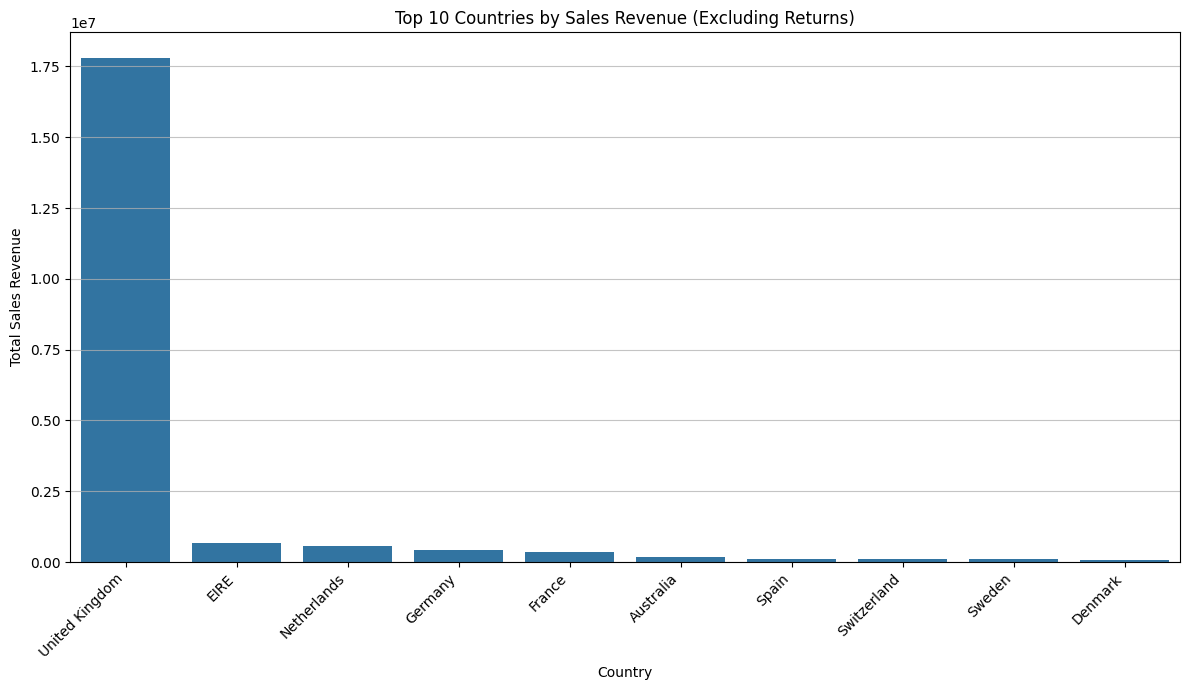

In [ ]:
country_sales = online_retail_eda.groupby('country')['line_revenue'].sum().sort_values(ascending=False).reset_index()

print('Top 10 Countries by Sales Revenue:')
display(country_sales.head(10))

plt.figure(figsize=(12, 7))
sns.barplot(x='country', y='line_revenue', data=country_sales.head(10))
plt.title('Top 10 Countries by Sales Revenue (Excluding Returns)')
plt.xlabel('Country')
plt.ylabel('Total Sales Revenue')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

### Detailed Null Analysis for `online_retail_eda`

Although we performed a general null check earlier, let's look specifically at the `online_retail_eda` DataFrame, which excludes cancelled transactions, to confirm its completeness. Understanding the extent of missing values is vital for subsequent analysis.

In [ ]:
print('Percentage of missing values in each column of online_retail_eda:')
print(online_retail_eda.isna().mean().sort_values(ascending=False) * 100)

Percentage of missing values in each column of online_retail_eda:
customer_id        22.921323
invoice_no          0.000000
description         0.000000
quantity            0.000000
invoice_date        0.000000
stock_code          0.000000
unit_price          0.000000
country             0.000000
is_cancelled        0.000000
has_customer_id     0.000000
line_revenue        0.000000
year_sheet          0.000000
invoice_day         0.000000
invoice_month       0.000000
dtype: float64


### Summary Statistics for `online_retail_eda`

We briefly looked at `describe()` earlier, but let's re-examine the descriptive statistics for our main EDA DataFrame (`online_retail_eda`) to get a quick overview of the central tendency, dispersion, and shape of its distribution for numerical data.

In [ ]:
display(online_retail_eda.describe())

,quantity,invoice_date,unit_price,customer_id,line_revenue
count,1.029609e+06,1029609,1.029609e+06,793609.000000,1.029609e+06
mean,1.105795e+01,2011-01-03 19:35:55.374282752,4.094842e+00,15325.072507,2.031246e+01
min,1.000000e+00,2009-12-01 07:45:00,1.000000e-03,12346.000000,1.000000e-03
25%,1.000000e+00,2010-07-12 10:54:00,1.250000e+00,13975.000000,4.130000e+00
50%,3.000000e+00,2010-12-07 18:36:00,2.100000e+00,15255.000000,1.008000e+01
75%,1.200000e+01,2011-07-24 12:05:00,4.150000e+00,16797.000000,1.770000e+01
max,8.099500e+04,2011-12-09 12:50:00,2.511109e+04,18287.000000,1.684696e+05
std,1.272405e+02,NaN,5.174728e+01,1697.397406,2.042938e+02


### Distribution Plots for Key Numerical Variables

We have already visualized the distributions for `quantity` and `unit_price`. Let's also look at the distribution of `line_revenue` to understand the revenue generated per transaction line.

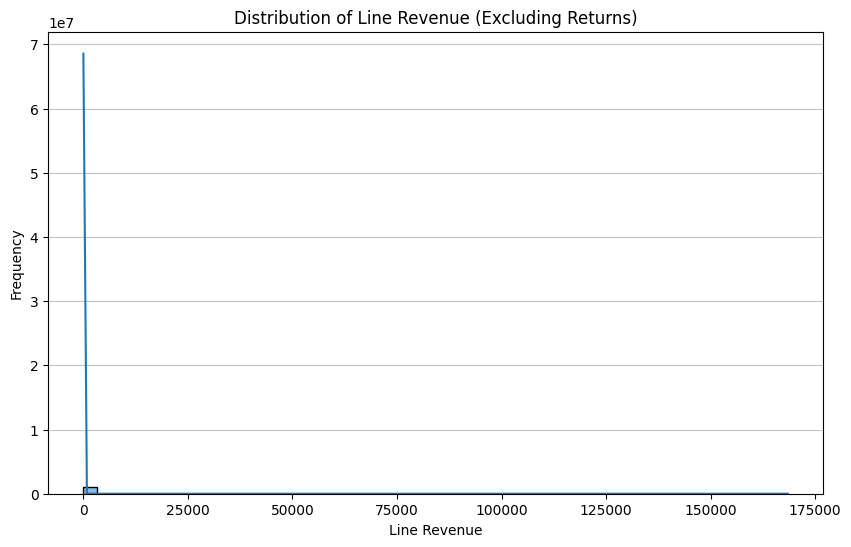

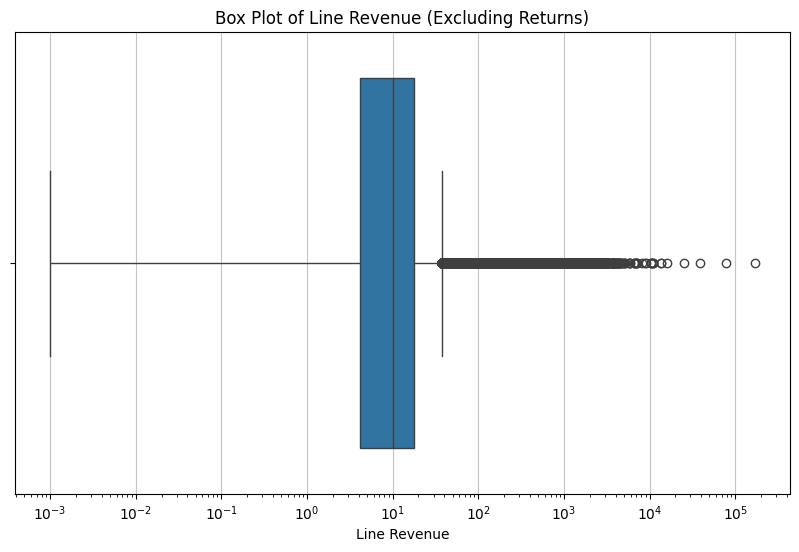

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(online_retail_eda['line_revenue'], bins=50, kde=True)
plt.title('Distribution of Line Revenue (Excluding Returns)')
plt.xlabel('Line Revenue')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x=online_retail_eda['line_revenue'])
plt.title('Box Plot of Line Revenue (Excluding Returns)')
plt.xlabel('Line Revenue')
plt.xscale('log') # Use a log scale for better visualization
plt.grid(axis='x', alpha=0.75)
plt.show()

### Correlation Heatmap

To understand the linear relationships between numerical variables, let's create a correlation heatmap. This will help identify highly correlated features, which can be useful for feature selection or understanding underlying data patterns.

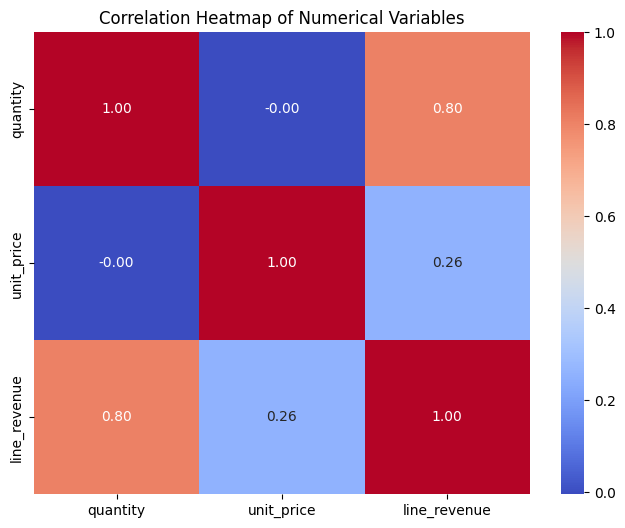

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(online_retail_eda[['quantity', 'unit_price', 'line_revenue']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

### Feature Engineering: Building an RFM Table

Recency, Frequency, Monetary (RFM) analysis is a marketing technique used to determine quantitatively which customers are the best by examining how recently a customer has purchased (Recency), how often they purchase (Frequency), and how much money they spend (Monetary).

To build our RFM table, we'll follow these steps:
1.  **Calculate Recency**: Days since the last purchase.
2.  **Calculate Frequency**: Total number of unique orders.
3.  **Calculate Monetary**: Total sum of purchases.
4.  **Handle missing Customer IDs**: RFM requires customer identification, so we'll drop rows where `customer_id` is missing.
5.  **Log-transform RFM features**: To reduce skewness and normalize the distributions.
6.  **Standardize features**: Using `StandardScaler` to ensure all features contribute equally to further analysis.

In [ ]:
import datetime as dt
import pandas as pd
import numpy as np

# --- Start RFM Calculation ---

# Drop rows with missing customer_id for RFM analysis
rfm_df = online_retail_eda.dropna(subset=['customer_id']).copy()

# Convert customer_id to integer type after dropping NaNs
rfm_df['customer_id'] = rfm_df['customer_id'].astype(int)

# Calculate snapshot_date as one day after the latest invoice date in rfm_df
snapshot_date = rfm_df['invoice_date'].max() + dt.timedelta(days=1)
print(f"Snapshot date set to: {snapshot_date}")

Snapshot date set to: 2011-12-10 12:50:00


#### 1. Calculate Recency

Recency is calculated as the number of days between each customer's last purchase date and a chosen `snapshot_date`. We'll use the day after the latest invoice date in our dataset as the `snapshot_date` to ensure all recency values are positive.

In [ ]:
recency_df = rfm_df.groupby('customer_id')['invoice_date'].max().reset_index()
recency_df['recency'] = (snapshot_date - recency_df['invoice_date']).dt.days
recency_df = recency_df[['customer_id', 'recency']]
print("First 5 rows of Recency DF:")
display(recency_df.head())

First 5 rows of Recency DF:


,customer_id,recency
0,12346,326
1,12347,2
2,12348,75
3,12349,19
4,12350,310


#### 2. Calculate Frequency

Frequency is the total number of unique orders (invoices) made by each customer.

In [ ]:
frequency_df = rfm_df.groupby('customer_id')['invoice_no'].nunique().reset_index()
frequency_df.rename(columns={'invoice_no': 'frequency'}, inplace=True)
print("First 5 rows of Frequency DF:")
display(frequency_df.head())

First 5 rows of Frequency DF:


,customer_id,frequency
0,12346,12
1,12347,8
2,12348,5
3,12349,4
4,12350,1


#### 3. Calculate Monetary Value

Monetary value is the total `line_revenue` generated by each customer.

In [ ]:
monetary_df = rfm_df.groupby('customer_id')['line_revenue'].sum().reset_index()
monetary_df.rename(columns={'line_revenue': 'monetary'}, inplace=True)
print("First 5 rows of Monetary DF:")
display(monetary_df.head())

First 5 rows of Monetary DF:


,customer_id,monetary
0,12346,77556.46
1,12347,5633.32
2,12348,2019.40
3,12349,4428.69
4,12350,334.40


#### 4. Combine RFM features into a single DataFrame

Now, we merge these three DataFrames into a single `rfm_combined_df`.

In [ ]:
rfm_combined_df = recency_df.merge(frequency_df, on='customer_id')
rfm_combined_df = rfm_combined_df.merge(monetary_df, on='customer_id')
print("First 5 rows of Combined RFM DF:")
display(rfm_combined_df.head())

First 5 rows of Combined RFM DF:


,customer_id,recency,frequency,monetary
0,12346,326,12,77556.46
1,12347,2,8,5633.32
2,12348,75,5,2019.40
3,12349,19,4,4428.69
4,12350,310,1,334.40


#### Inspecting RFM Distribution (Original Scale)

Let's visualize the distribution of the raw Recency, Frequency, and Monetary values before log transformation. This will help us understand their inherent skewness.

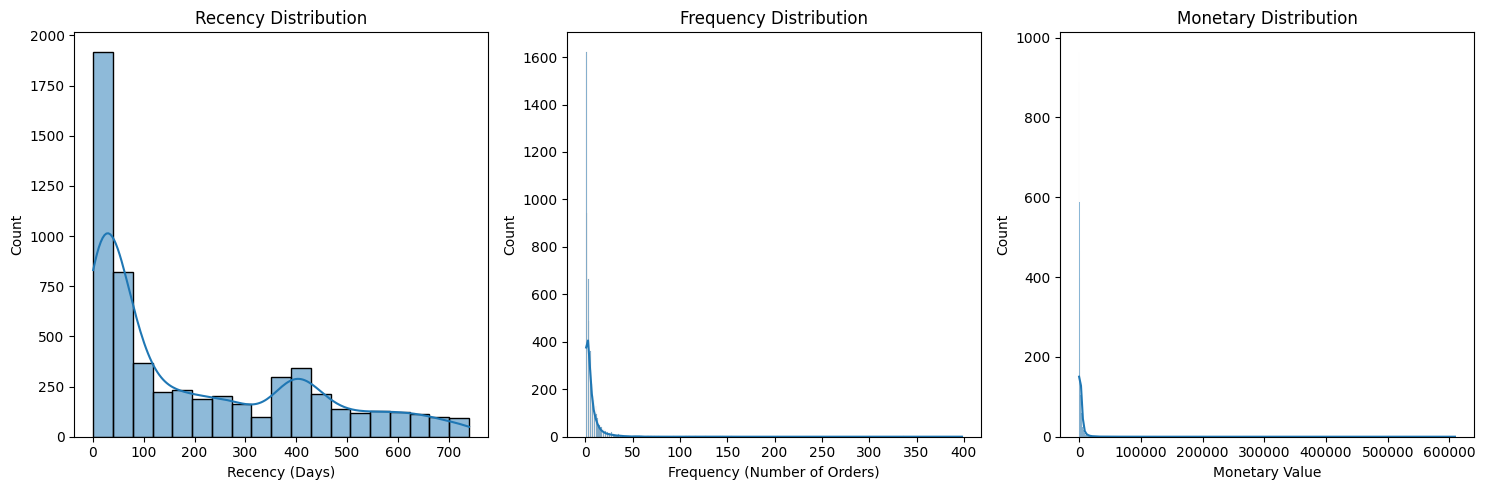

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(rfm_combined_df['recency'], kde=True)
plt.title('Recency Distribution')
plt.xlabel('Recency (Days)')
plt.ylabel('Count')

plt.subplot(1, 3, 2)
sns.histplot(rfm_combined_df['frequency'], kde=True)
plt.title('Frequency Distribution')
plt.xlabel('Frequency (Number of Orders)')
plt.ylabel('Count')

plt.subplot(1, 3, 3)
sns.histplot(rfm_combined_df['monetary'], kde=True)
plt.title('Monetary Distribution')
plt.xlabel('Monetary Value')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

### Correlation Heatmap of RFM Features

Let's visualize the correlation between the Recency, Frequency, and Monetary features to understand their linear relationships before any transformations.

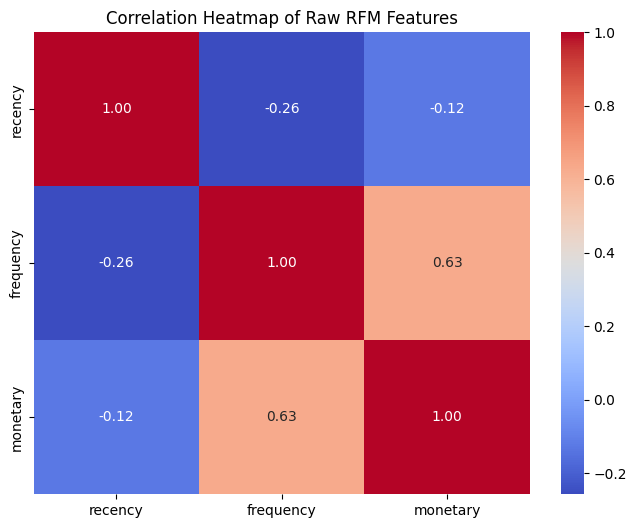

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(rfm_combined_df[['recency', 'frequency', 'monetary']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Raw RFM Features')
plt.show()

#### 5. Log Transformation and Standardization

RFM values often have highly skewed distributions. To ensure that these features contribute equally to clustering or other machine learning algorithms, we'll apply a log transformation (specifically `np.log1p` which handles zero values) and then standardize them using `StandardScaler`.

In [ ]:
from sklearn.preprocessing import StandardScaler

rfm_log_transformed = rfm_combined_df[['recency', 'frequency', 'monetary']].apply(np.log1p)
scaler = StandardScaler()
X = scaler.fit_transform(rfm_log_transformed)
X_df = pd.DataFrame(X, columns=['recency_scaled', 'frequency_scaled', 'monetary_scaled'], index=rfm_combined_df['customer_id'])
print("First 5 rows of the log-transformed and standardized RFM features (Feature Matrix X):")
display(X_df.head())

First 5 rows of the log-transformed and standardized RFM features (Feature Matrix X):


,recency_scaled,frequency_scaled,monetary_scaled
customer_id,,,
12346,0.856701,1.254496,3.188867
12347,-2.151979,0.800166,1.300602
12348,-0.079138,0.299207,0.562057
12349,-0.935308,0.073946,1.127378
12350,0.824527,-1.058146,-0.731087
